# 06 · Explicabilidade: por que a rede disse "risco alto"?

Uma rede neural não entrega regras legíveis. Em saúde, a equipe precisa saber **quais
fatores** levaram a um alerta. Três técnicas, como nos exercícios de crédito e de
diamantes:

1. **Importância por permutação** (global) — quanto a AUC cai quando uma variável é
   embaralhada.
2. **SHAP** (global e local) — divide a probabilidade de cada paciente entre as variáveis,
   com base em teoria dos jogos.
3. **LIME** (local) — ajusta um modelo linear simples ao redor de um paciente.

As explicações são feitas na **escala original** das variáveis (mmHg, anos, kg), e não
nas colunas padronizadas que a rede vê — a função de previsão aplica o pré-processador por
dentro.

In [1]:
import sys
from pathlib import Path

# Permite importar `src` mesmo fora do ambiente do uv (ex.: Colab com o repositório clonado).
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import roc_auc_score

from src import config
from src.data.dados import preparar
from src.model import treino
from src.utils.io import configurar_estilo, salvar_figura, salvar_tabela

configurar_estilo()
SECAO = "06-explicabilidade"

if not treino.ARQUIVO_MODELO.exists():
    treino.treinar_modelo_final()
modelo, preprocessador, metadados = treino.carregar_modelo_final()
LIMIAR = metadados["limiar"]
particao = preparar()
bruto_teste = particao.bruto_teste
y_teste = particao.y_teste
ROTULOS = [config.ROTULOS[c] for c in config.ENTRADAS]


def prever(dados) -> np.ndarray:
    """Probabilidade a partir de dados na escala original (DataFrame ou array)."""
    dados = pd.DataFrame(np.asarray(dados), columns=config.ENTRADAS)
    return treino.prever_bruto(modelo, preprocessador, dados)


print(f"AUC no teste: {roc_auc_score(y_teste, prever(bruto_teste)):.4f}   limiar: {LIMIAR:.3f}")

AUC no teste: 0.8014   limiar: 0.382


## 1. Importância por permutação

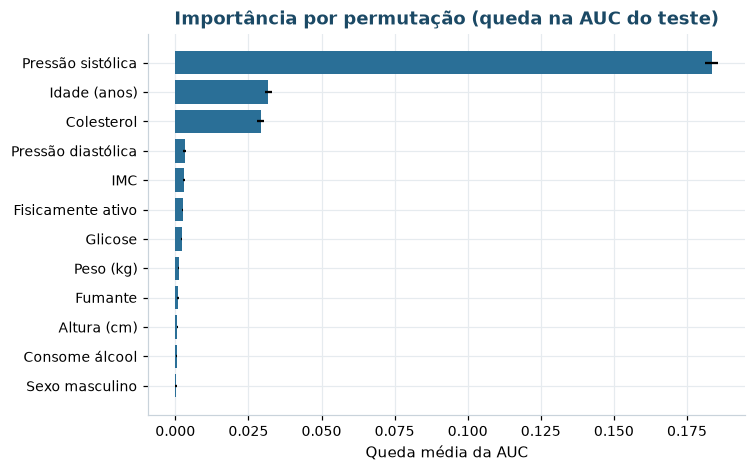

In [2]:
rng = np.random.default_rng(config.SEMENTE)
auc_base = roc_auc_score(y_teste, prever(bruto_teste))
linhas = []
for coluna in config.ENTRADAS:
    quedas = []
    for _ in range(5):
        embaralhado = bruto_teste.copy()
        embaralhado[coluna] = rng.permutation(embaralhado[coluna].to_numpy())
        quedas.append(auc_base - roc_auc_score(y_teste, prever(embaralhado)))
    linhas.append({"variavel": config.ROTULOS[coluna], "queda_auc": np.mean(quedas), "desvio": np.std(quedas)})

permutacao = pd.DataFrame(linhas).set_index("variavel").sort_values("queda_auc")
fig, eixo = plt.subplots(figsize=(7, 4.5))
eixo.barh(permutacao.index, permutacao["queda_auc"], xerr=permutacao["desvio"], color=config.AZUL_COBALTO)
eixo.set(title="Importância por permutação (queda na AUC do teste)", xlabel="Queda média da AUC")
salvar_figura(fig, SECAO, "importancia-permutacao", permutacao)
plt.show()

Embaralhar a **pressão sistólica** derruba a AUC em ≈ 0,19 — cinco vezes mais que qualquer
outra variável. Depois vêm **idade** e **colesterol** (≈ 0,03 cada); todas as demais ficam
abaixo de 0,005. Hábitos autodeclarados (fumo, álcool) quase não pesam, o que bate com o
que a análise exploratória do projeto de agrupamento já tinha observado.

> Peso, altura e IMC carregam informação redundante: embaralhar um deles isoladamente
> subestima a importância do bloco "tamanho corporal".

## 2. SHAP

`KernelExplainer` é agnóstico ao modelo: trata a rede como caixa-preta e só precisa da
função de previsão. Custa caro, então explicamos uma amostra de 300 pacientes do teste
contra um fundo de 100 pacientes do treino.

In [3]:
fundo = shap.sample(particao.bruto_treino, 100, random_state=config.SEMENTE)
amostra = bruto_teste.sample(300, random_state=config.SEMENTE)

explicador = shap.KernelExplainer(prever, fundo.to_numpy())
valores_shap = explicador.shap_values(amostra.to_numpy(), nsamples=300, silent=True)
explicacao = shap.Explanation(
    values=valores_shap, base_values=np.full(len(amostra), explicador.expected_value),
    data=amostra.to_numpy(), feature_names=ROTULOS,
)
print(f"Probabilidade média do fundo (valor-base): {explicador.expected_value:.3f}")

Probabilidade média do fundo (valor-base): 0.506


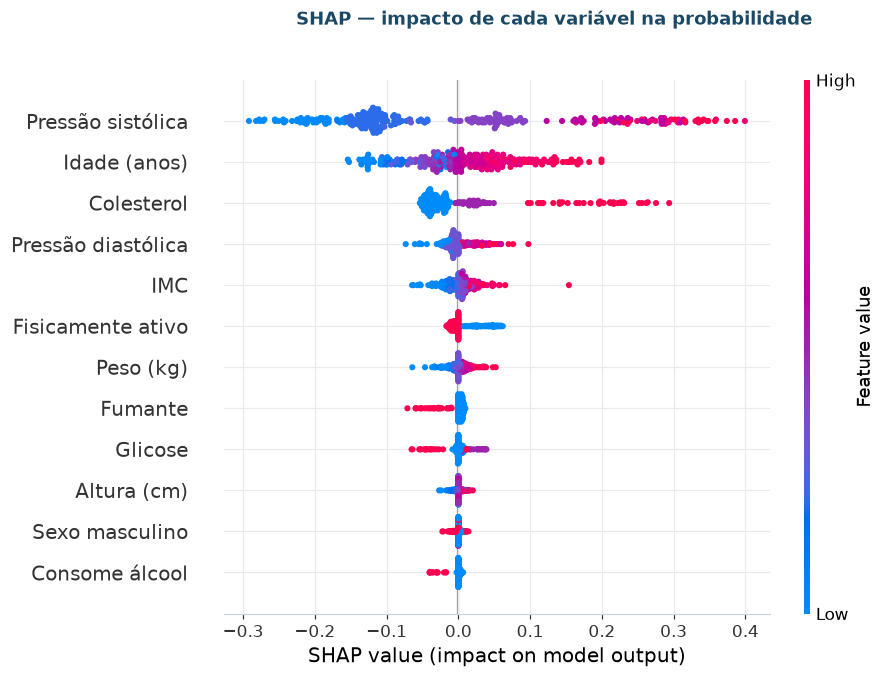

In [4]:
shap.plots.beeswarm(explicacao, max_display=12, show=False)
fig = plt.gcf()
fig.suptitle("SHAP — impacto de cada variável na probabilidade", fontweight="bold", color=config.AZUL_PROFUNDO)
media_abs = pd.Series(np.abs(valores_shap).mean(axis=0), index=ROTULOS, name="shap_medio_abs")
salvar_figura(fig, SECAO, "shap-beeswarm", media_abs.sort_values(ascending=False).to_frame())
plt.show()

Cada ponto é um paciente. Pontos vermelhos (valor alto da variável) à direita indicam que
valores altos **aumentam** o risco previsto: é o caso de pressão, idade e colesterol, e em
menor grau de peso e pressão diastólica. Para **atividade física** o efeito é o inverso: ser
ativo reduz a probabilidade.

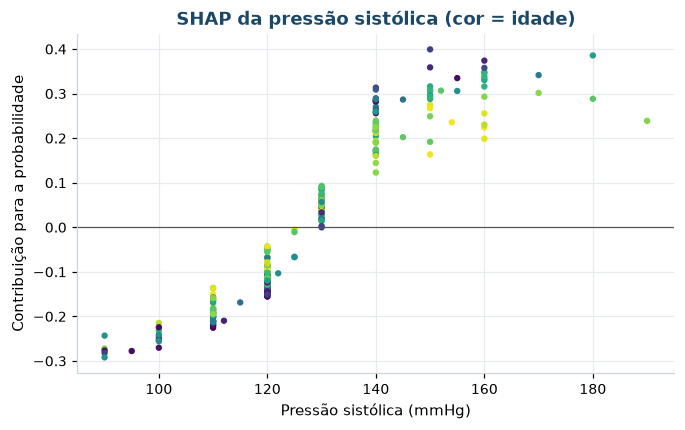

In [5]:
fig, eixo = plt.subplots(figsize=(7, 4))
i_pa = config.ENTRADAS.index("ap_hi")
eixo.scatter(amostra["ap_hi"], valores_shap[:, i_pa], s=10, c=amostra["idade_anos"], cmap="viridis")
eixo.axhline(0, color="#555", linewidth=0.8)
eixo.set(title="SHAP da pressão sistólica (cor = idade)", xlabel="Pressão sistólica (mmHg)",
         ylabel="Contribuição para a probabilidade")
dependencia = pd.DataFrame({"ap_hi": amostra["ap_hi"].to_numpy(), "shap_ap_hi": valores_shap[:, i_pa]})
salvar_figura(fig, SECAO, "shap-dependencia-pressao", dependencia)
plt.show()

A contribuição da pressão muda de sinal entre 125 e 130 mmHg, sobe rápido até ≈ 140 mmHg e
daí em diante praticamente **estabiliza** — a mesma forma de saturação vista na superfície
de decisão do notebook 04.

## 3. Explicação de pacientes individuais (SHAP + LIME)

Um paciente de alto risco e um de baixo risco, lado a lado.

[alto risco] P = 0.92 → investigar. Fatores principais: Pressão sistólica = 190 (↑ 0.24); Colesterol = 3 (↑ 0.10); Pressão diastólica = 110 (↑ 0.03)
[baixo risco] P = 0.03 → rotina. Fatores principais: Pressão sistólica = 90 (↓ 0.28); Idade (anos) = 40 (↓ 0.12); Pressão diastólica = 60 (↓ 0.02)


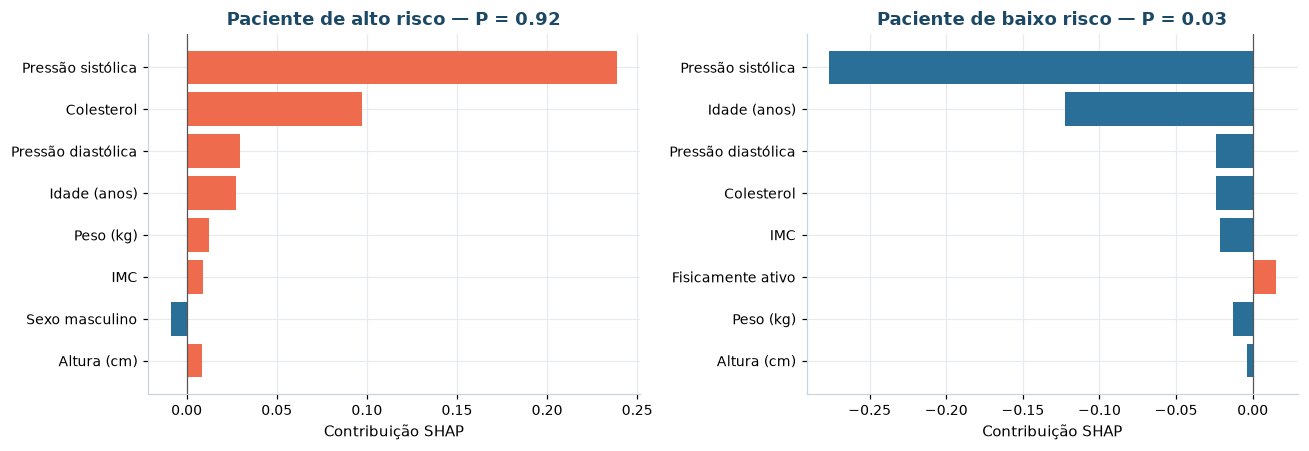

In [6]:
probs_amostra = prever(amostra)
posicoes = {"alto risco": int(np.argmax(probs_amostra)), "baixo risco": int(np.argmin(probs_amostra))}


def frase(posicao: int, n: int = 3) -> str:
    contrib = valores_shap[posicao]
    ordem = np.argsort(np.abs(contrib))[::-1][:n]
    paciente = amostra.iloc[posicao]
    partes = [
        f"{ROTULOS[i]} = {paciente.iloc[i]:.0f} ({'↑' if contrib[i] > 0 else '↓'} {abs(contrib[i]):.2f})"
        for i in ordem
    ]
    decisao = "investigar" if probs_amostra[posicao] >= LIMIAR else "rotina"
    return f"P = {probs_amostra[posicao]:.2f} → {decisao}. Fatores principais: " + "; ".join(partes)


fig, eixos = plt.subplots(1, 2, figsize=(12, 4.2))
linhas = []
for eixo, (nome, pos) in zip(eixos, posicoes.items()):
    contrib = pd.Series(valores_shap[pos], index=ROTULOS).sort_values(key=np.abs).tail(8)
    eixo.barh(contrib.index, contrib, color=[config.CORAL if v > 0 else config.AZUL_COBALTO for v in contrib])
    eixo.axvline(0, color="#555", linewidth=0.8)
    eixo.set(title=f"Paciente de {nome} — P = {probs_amostra[pos]:.2f}", xlabel="Contribuição SHAP")
    print(f"[{nome}] {frase(pos)}")
    linhas.append(contrib.rename(nome))
fig.tight_layout()
salvar_figura(fig, SECAO, "shap-pacientes", pd.concat(linhas, axis=1))
plt.show()

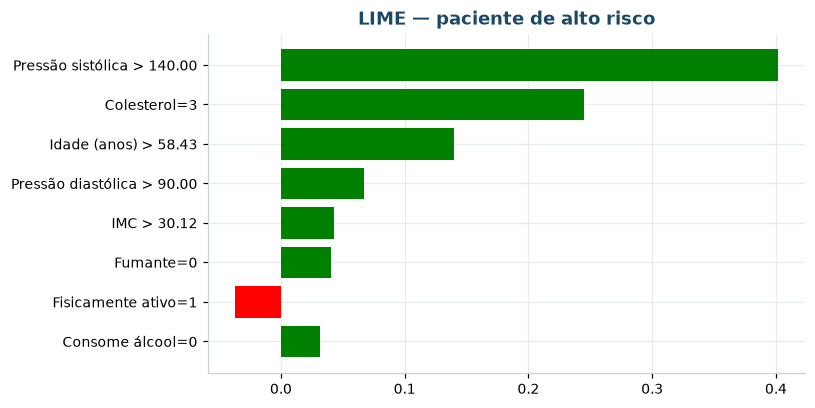

,regra,peso
0,Pressão sistólica > 140.00,0.401508
1,Colesterol=3,0.244816
2,Idade (anos) > 58.43,0.139641
3,Pressão diastólica > 90.00,0.067531
4,IMC > 30.12,0.042984
5,Fumante=0,0.040151
6,Fisicamente ativo=1,-0.036877
7,Consome álcool=0,0.031689


In [7]:
categoricas = [config.ENTRADAS.index(c) for c in config.ORDINAIS + config.BINARIAS]
lime = LimeTabularExplainer(
    training_data=particao.bruto_treino.to_numpy(),
    feature_names=ROTULOS,
    class_names=["sem doença", "com doença"],
    categorical_features=categoricas,
    mode="classification",
    discretize_continuous=True,
    random_state=config.SEMENTE,
)


def prever_duas_classes(dados):
    p = prever(dados)
    return np.c_[1 - p, p]


pos = posicoes["alto risco"]
exp_lime = lime.explain_instance(amostra.iloc[pos].to_numpy(), prever_duas_classes, num_features=8, num_samples=3000)
fig = exp_lime.as_pyplot_figure()
fig.set_size_inches(7, 4)
plt.title("LIME — paciente de alto risco")
salvar_figura(fig, SECAO, "lime-alto-risco", pd.DataFrame(exp_lime.as_list(), columns=["regra", "peso"]))
plt.show()
pd.DataFrame(exp_lime.as_list(), columns=["regra", "peso"])

## Conclusões

* As três técnicas concordam: **pressão sistólica** domina com folga, seguida de
  **idade** e **colesterol**. A rede reproduz o conhecimento clínico estabelecido — um bom
  sinal de que aprendeu relações reais, e não artefatos da base.
* **Cuidado com fumo e álcool:** no LIME, ser fumante ou consumir álcool aparece
  *reduzindo* o risco. É um paradoxo conhecido desta base (hábitos autodeclarados e
  confundidos com sexo e idade), não um efeito protetor. A explicação mostra o que o modelo
  aprendeu, não uma relação causal — e é exatamente para achar esse tipo de coisa que ela
  serve.
* SHAP e LIME explicam cada paciente em termos que a equipe de enfermagem entende
  ("pressão 180 aumentou o risco"), o que torna o alerta auditável.
* A aplicação Streamlit usa uma versão rápida dessa ideia (troca de cada variável pelo
  valor típico) para explicar a previsão de um paciente digitado na hora.